In [3]:
import numpy as np

**Numpy** provides a convenient interface to work with array structures. It provides an array called ndarray short for n-dimensional array. It is mostly implemented in C. It uses contiguous blocks of memory that can be efficiently cached by the CPU. This comes at a cost, the arrays have a fixed size and are homogeneous.

## Python for loop approach

In [2]:
def python_forloop_list_approach(x, w):
    z = 0.
    for i in range(len(x)):
        z += x[i]*w[i]
    return z

a = [1., 2., 3.]
b = [4., 5., 6.]

print(python_forloop_list_approach(a,b))

large_a = list(range(1000))
large_b = list(range(1000))

%timeit python_forloop_list_approach(large_a, large_b)

32.0
84.8 μs ± 2.87 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Using numpy

In [3]:
import numpy as np

def numpy_dot_product(x, w):
    return x.dot(w)

large_a = np.arange(1000)
large_b = np.arange(1000)
%timeit numpy_dot_product(large_a, large_b)

1.58 μs ± 28 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [4]:
a = [1., 2., 3.]
np.array(a)


array([1., 2., 3.])

In [7]:
lst = [[1,2,3], 
       [4,5,6]]

ary2d = np.array(lst)
ary2d
ary2d.dtype

dtype('int64')

In [12]:
int32ary = ary2d.astype(np.int32)
print(int32ary.dtype)
print(ary2d.ndim)
print(ary2d.shape)


int32
2
(2, 3)


## Array construction Routines

In [15]:
np.ones((3,4), dtype=np.int32)

array([[1, 1, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 1]], dtype=int32)

In [16]:
np.zeros((4,5), dtype=np.int32)

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=int32)

In [18]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [19]:
np.diag((1,2,3))

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])

In [20]:
np.arange(4,10)

array([4, 5, 6, 7, 8, 9])

## Numpy Array Math and Universal Functions

Vectorisation: numpy provides vectorized wrappers for performing element-wise operations via so called u-funcs(universal functions).


In [1]:
lst = [[1,2,3], [4,5,6]]

for row_idx, row_val in enumerate(lst):
    for col_idx, col_val in enumerate(row_val):
        lst[row_idx][col_idx] += 1

lst


[[2, 3, 4], [5, 6, 7]]

In [2]:
lst = [[1,2,3], [4,5,6]]
[[cell + 1 for cell in row] for row in lst]

[[2, 3, 4], [5, 6, 7]]

In [6]:
arr = np.array([[1,2,3], [4,5,6]])
arr = np.add(arr, 1)
arr

array([[2, 3, 4],
       [5, 6, 7]])

In [7]:
"use operator overloading instead of functions"
arr = np.array([[1,2,3], [4,5,6]])
arr+1

array([[2, 3, 4],
       [5, 6, 7]])

In [13]:
"reducing over an axes row or column"
print("along row")
arr = np.array([[1,2,3], [4,5,6]])
result_row = np.add.reduce(arr, axis=1)
print(result)
print("along col")
result_col = np.add.reduce(arr)
print(result_col)

along row
[ 6 15]
along col
[5 7 9]


## Numpy Broadcasting
Broadcasting allows us to perform vectorized operations between two arrays even when the dimensions don't match by creating implicit multi-dimensional grids. 

In [14]:
arr1 = np.array([1,2,3])
arr2 = np.array([[4,5,6], [7,8,9]])

arr1 + arr2

array([[ 5,  7,  9],
       [ 8, 10, 12]])

## Numpy advanced indexing - Memory view and Copies
```
arr = np.array([1,2,3,4,5])
```
When we do integer based indexing `arr[0]` or `arr[:,2]` we are creating memory views since it avoids making unnecessary copies of arrays to save memory. 

In [26]:
"modifying the slice modifies the original array, because the slice gives a view of the array"

arr = np.array([[1,2,3], [4,5,6]])
print(arr, "<=original array\n")
first_row = arr[0]
print(first_row, "<=first row")

first_row += 99
print(first_row, "<=after add\n")

print("original array changes")
print(arr)

[[1 2 3]
 [4 5 6]] <=original array

[1 2 3] <=first row
[100 101 102] <=after add

original array changes
[[100 101 102]
 [  4   5   6]]


In [28]:
"To avoid scenarios where we don't intend to modify the array use the `copy` method"

arr = np.array([[1,2,3], [4,5,6]])
print(arr, "<=original array\n")

"use copy method with the slice"
first_row = arr[0].copy()
print(first_row, "<=first row")

first_row += 99
print(first_row, "<=after add\n")

print("original array remains same")
print(arr)

[[1 2 3]
 [4 5 6]] <=original array

[1 2 3] <=first row
[100 101 102] <=after add

original array remains same
[[1 2 3]
 [4 5 6]]


## Fancy Indexing

In addition to basic indexing and slicing numpy supports advanced indexing, called fancy indexing. You can use list or tuple objects of non-contiguous sequences, it cannot return a view. It always returns a copy.

In [3]:
arr = np.array([[1,2,3], [4,5,6]])
print(arr, "<= original array \n")

"return first and last col"
arr_cp = arr[:, [0,2]]
print(arr_cp, "<=sliced array with list \n")

"Using boolean masks for indexing"
## generate mask
greate_mask = arr > 3
print(greate_mask, "<= mask\n")

## apply mask
result_masked = arr[greate_mask]
print(result_masked, "masked result \n")

## chain using & and |
mask = (arr > 3) & (arr %2 == 0)
print(mask, "chained mask \n")
result_masked = arr[mask]
print(result_masked, "chaing masked result \n")

[[1 2 3]
 [4 5 6]] <= original array 

[[1 3]
 [4 6]] <=sliced array with list 

[[False False False]
 [ True  True  True]] <= mask

[4 5 6] masked result 

[[False False False]
 [ True False  True]] chained mask 

[4 6] chaing masked result 



## Random Number generation

In [5]:
np.random.seed(123)
np.random.rand(3)

array([0.69646919, 0.28613933, 0.22685145])

In [12]:
arr_1D = np.array([1,2,3,4,5,6])
arr_2D = arr_1D.reshape(2,3)
arr_2D
arr_2D_cp = arr_2D.copy()
arr_2D_cp
arr_2D_cp[0][1] = 99
print(arr_2D_cp)
print(arr_2D)

[[ 1 99  3]
 [ 4  5  6]]
[[1 2 3]
 [4 5 6]]


## Linear algebra with numpy

In [4]:
row_vector = np.array([1,2,3])
row_vector
col_vector = row_vector.reshape([-1,1])
col_vector

array([[1],
       [2],
       [3]])

In [5]:
matrix = np.array([[1, 2, 3], 
                   [4, 5, 6]])
result = np.matmul(matrix, col_vector)
result

array([[14],
       [32]])

In [7]:
print(matrix @ col_vector, "with col vector")
print(matrix @ row_vector, "with row vector")

[[14]
 [32]] with col vector
[14 32] with row vector


In [8]:
print(matrix @ matrix.transpose(), "with transpose")

[[14 32]
 [32 77]] with transpose


In [1]:
import matplotlib.pyplot as plt

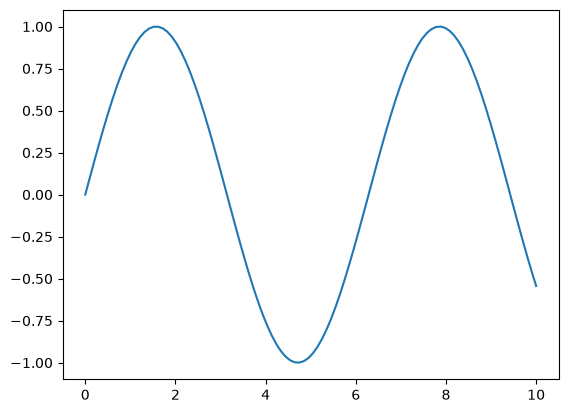

In [4]:
x = np.linspace(0, 10, 100)
plt.plot(x, np.sin(x))

plt.show()